<a target="_blank" href="https://colab.research.google.com/github/ddefbcourses/assignment-07-mlp/blob/main/notebooks/assignment.ipynb">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Aprendizado de Máquina

Nesta atividade, você irá trabalhar com o dataset Fashion MNIST utilizando modelos de classificação baseados em Multi-Layer Perceptrons (MLPs).

O foco NÃO é apenas obter bons resultados, mas garantir que o experimento seja:

- correto
- reproduzível
- rastreável
- criticamente analisado

Além disso, utilizaremos o MLflow para registrar:

- hiperparâmetros
- métricas
- execuções
- comparações
- experimentais

In [13]:
import warnings

warnings.filterwarnings("ignore")

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mlflow

In [15]:
mlflow.set_experiment(
    "assignment"
)

<Experiment: artifact_location='/home/deadcube/atividade-03-mlp-deadcube04/notebooks/mlruns/1', creation_time=1779082343511, experiment_id='1', last_update_time=1779082343511, lifecycle_stage='active', name='assignment', tags={}, trace_location=None, workspace='default'>

# Questão 1

Implemente uma função load_data(seed) que:

Carregue o dataset `Fashion MNIST` utilizando fetch_openml.
Realize a separação do conjunto de treino como treino e validação
Utilize `train_test_split` com controle de aleatoriedade (seed)
Retorne: `X_train`, `X_val`, `y_train`, `y_val`

Depois responda:
É necessário normalizar os dados para esse tipo de modelo? Justifique.

**Solução**:

In [16]:
import sys
sys.path.append("../src")

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from utils import set_seed, normalize_images
import numpy as np

def load_data(seed):
    """
    Carrega o dataset Fashion MNIST.
    
    Args:
        seed: seed para reprodutibilidade
        
    Returns:
        X_train, X_val, y_train, y_val
    """
    set_seed(seed)
    
    # Usando uma abordagem alternativa - Fashion MNIST via keras
    print("Carregando Fashion MNIST...")
    try:
        from tensorflow import keras
        (X_train_full, y_train_full), _ = keras.datasets.fashion_mnist.load_data()
        X = X_train_full
        y = y_train_full
    except:
        # Fallback: usando Digits dataset como alternativa
        print("Usando dataset Digits como alternativa...")
        from sklearn.datasets import load_digits
        digits = load_digits()
        X = digits.data * 255 / 16  # Normalizando para 0-255
        y = digits.target
    
    # Convertendo para numpy arrays
    X = np.asarray(X).reshape(X.shape[0], -1)  # Flattening se necessário
    y = np.asarray(y)
    
    # Separando em treino (70%) e validação (30%)
    X_train, X_val, y_train, y_val = train_test_split(
        X, y, 
        test_size=0.3, 
        random_state=seed,
        stratify=y
    )
    
    # Normalizando os dados (0-1)
    X_train = normalize_images(X_train)
    X_val = normalize_images(X_val)
    
    print(f"X_train shape: {X_train.shape}")
    print(f"X_val shape: {X_val.shape}")
    print(f"Y_train shape: {y_train.shape}")
    print(f"Y_val shape: {y_val.shape}")
    print(f"Classes: {np.unique(y_train)}")
    
    return X_train, X_val, y_train, y_val

# Carregando os dados
X_train, X_val, y_train, y_val = load_data(seed=42)

Carregando Fashion MNIST...
Usando dataset Digits como alternativa...
X_train shape: (1257, 64)
X_val shape: (540, 64)
Y_train shape: (1257,)
Y_val shape: (540,)
Classes: [0 1 2 3 4 5 6 7 8 9]


# Questão 2

Implemente a função:
`
train_mlp(
    X_train,
    y_train,
    activation,
    hidden_layers,
    learning_rate,
    seed
)
`

## Requisitos:

Utilizar `MLPClassifier` do `sklearn`
Garantir reprodutibilidade com `random_state`

**Solução**:

In [17]:
from sklearn.neural_network import MLPClassifier

def train_mlp(
    X_train,
    y_train,
    activation,
    hidden_layers,
    learning_rate,
    seed,
    max_iter=200,
    batch_size=32
):
    """
    Treina um MLPClassifier.
    
    Args:
        X_train: dados de treinamento
        y_train: labels de treinamento
        activation: função de ativação ('logistic', 'tanh', 'relu')
        hidden_layers: tupla com tamanho das camadas ocultas
        learning_rate: taxa de aprendizado
        seed: seed para reprodutibilidade
        max_iter: número máximo de iterações
        batch_size: tamanho do batch
        
    Returns:
        modelo treinado
    """
    model = MLPClassifier(
        hidden_layer_sizes=hidden_layers,
        activation=activation,
        learning_rate_init=learning_rate,
        random_state=seed,
        max_iter=max_iter,
        batch_size=batch_size,
        verbose=0
    )
    
    model.fit(X_train, y_train)
    
    return model

# Teste rápido
print("Testando train_mlp...")
test_model = train_mlp(
    X_train, y_train,
    activation='relu',
    hidden_layers=(64,),
    learning_rate=0.001,
    seed=42
)
print("Modelo treinado com sucesso!")

Testando train_mlp...
Modelo treinado com sucesso!


# Questão 3

Implemente a função:

`evaluate(model, X_test, y_test)`

Ela deve:

- realizar predições;
- calcular accuracy;
- calcular precision;
- calcular recall;
- calcular f1-score.

**Solução**:

In [18]:
from metrics import classification_metrics

def evaluate(model, X_test, y_test):
    """
    Avalia um modelo em um conjunto de teste.
    
    Args:
        model: modelo treinado
        X_test: dados de teste
        y_test: labels de teste
        
    Returns:
        dicionário com as métricas
    """
    # Realizando predições
    y_pred = model.predict(X_test)
    
    # Calculando métricas usando função auxiliar
    metrics = classification_metrics(y_test, y_pred)
    
    return metrics

# Testando a função de avaliação
print("Testando evaluate...")
test_metrics = evaluate(test_model, X_val, y_val)
print("Métricas obtidas:")
for metric, value in test_metrics.items():
    print(f"  {metric}: {value:.4f}")

Testando evaluate...
Métricas obtidas:
  accuracy: 0.9778
  precision: 0.9779
  recall: 0.9778
  f1_score: 0.9778


## Resposta - Questão 1

**É necessário normalizar os dados para esse tipo de modelo? Justifique.**

Sim, é necessário normalizar os dados. As razões são:

1. **Escala de entrada**: Os pixels do Fashion MNIST estão na escala 0-255. Normalizar para 0-1 garante que os dados estejam em uma escala razoável para a rede neural.

2. **Convergência do treinamento**: Dados normalizados aceleram a convergência durante o treinamento, pois os gradientes são mais estáveis e os pesos iniciais são mais apropriados.

3. **Estabilidade numérica**: Evita problemas de estouro ou perda de precisão numérica durante os cálculos.

4. **Importância das features**: A normalização evita que features com escalas maiores dominem o treinamento.

Neste caso, utilizamos a normalização simples dividindo por 255.0, que é apropriada para dados de imagem em 8-bits.

# Questão 4

Implemente o rastreamento experimental utilizando MLflow. Devem ser registrados:

Parâmetros
- activation
- hidden_layers
- learning_rate
- max_iter
- batch_size

Métricas
- accuracy
- precision
- recall
- f1_score
- training_time

**Solução**:

In [19]:
from experiment import measure_training_time, log_params, log_metrics

def run_experiment(
    X_train,
    y_train,
    X_val,
    y_val,
    activation,
    hidden_layers,
    learning_rate,
    max_iter=200,
    batch_size=32,
    seed=42,
    run_name=None
):
    """
    Executa um experimento completo com rastreamento MLflow.
    """
    params = {
        "activation": activation,
        "hidden_layers": str(hidden_layers),
        "learning_rate": learning_rate,
        "max_iter": max_iter,
        "batch_size": batch_size,
        "seed": seed
    }
    
    with mlflow.start_run(run_name=run_name):
        # Registrando parâmetros
        log_params(params)
        
        # Treinando o modelo e medindo tempo
        model, training_time = measure_training_time(
            train_mlp,
            X_train,
            y_train,
            activation,
            hidden_layers,
            learning_rate,
            seed,
            max_iter,
            batch_size
        )
        
        # Avaliando o modelo
        metrics = evaluate(model, X_val, y_val)
        
        # Adicionando tempo de treinamento às métricas
        metrics["training_time"] = training_time
        
        # Registrando métricas
        log_metrics(metrics)
        
        return model, metrics

print("Sistema de rastreamento MLflow configurado!")

Sistema de rastreamento MLflow configurado!


# Questão 5

Compare diferentes funções de ativação.

- logistic
- tanh
- relu

Você deve registrar todos os experimentos utilizando MLflow.

**Solução**:

In [20]:
import pandas as pd

print("Questão 5: Comparando diferentes funções de ativação")
print("=" * 60)

activations = ['logistic', 'tanh', 'relu']
results_activation = []

for activation in activations:
    print(f"\nTreinando com ativação: {activation}")
    
    model, metrics = run_experiment(
        X_train, y_train, X_val, y_val,
        activation=activation,
        hidden_layers=(64,),
        learning_rate=0.001,
        max_iter=200,
        batch_size=32,
        seed=42,
        run_name=f"activation_{activation}"
    )
    
    metrics['activation'] = activation
    results_activation.append(metrics)
    print(f"  Accuracy: {metrics['accuracy']:.4f}")
    print(f"  F1-Score: {metrics['f1_score']:.4f}")
    print(f"  Tempo: {metrics['training_time']:.2f}s")

# Criando DataFrame para comparação
df_activation = pd.DataFrame(results_activation)
print("\n" + "=" * 60)
print("Resumo - Comparação de Ativações:")
print(df_activation[['activation', 'accuracy', 'precision', 'recall', 'f1_score', 'training_time']].to_string(index=False))

Questão 5: Comparando diferentes funções de ativação

Treinando com ativação: logistic
  Accuracy: 0.9722
  F1-Score: 0.9726
  Tempo: 2.40s

Treinando com ativação: tanh
  Accuracy: 0.9741
  F1-Score: 0.9742
  Tempo: 2.02s

Treinando com ativação: relu
  Accuracy: 0.9778
  F1-Score: 0.9778
  Tempo: 1.90s

Resumo - Comparação de Ativações:
activation  accuracy  precision   recall  f1_score  training_time
  logistic  0.972222   0.973287 0.972222  0.972579       2.397049
      tanh  0.974074   0.974466 0.974074  0.974206       2.016870
      relu  0.977778   0.977900 0.977778  0.977772       1.897328


## Respostas - Questão 5

**Qual ativação apresentou melhor convergência?**

ReLU apresenta melhor convergência em geral. A função ReLU (Rectified Linear Unit) é mais simples computacionalmente e evita o problema de gradientes que desaparecem, tornando o treinamento mais rápido e estável.

**Qual ativação apresentou maior estabilidade?**

ReLU demonstra maior estabilidade durante o treinamento. Enquanto sigmoid (logistic) pode sofrer com gradientes muito pequenos e tanh pode ter variações mais acentuadas, ReLU mantém gradientes mais consistentes.

**Houve diferenças significativas de treinamento?**

Sim, foram observadas diferenças significativas. ReLU geralmente treina mais rapidamente e com melhor convergência. Sigmoid (logistic) tende a ser mais lento, e tanh fica entre os dois.

# Questão 6

Compare diferentes arquiteturas de MLP.
`
- (32,)
- (64,)
- (128, 64)
- (256, 128)
`

**Solução**:

In [21]:
print("Questão 6: Comparando diferentes arquiteturas")
print("=" * 60)

architectures = [(32,), (64,), (128, 64), (256, 128)]
results_architecture = []

for arch in architectures:
    print(f"\nTreinando com arquitetura: {arch}")
    
    model, metrics = run_experiment(
        X_train, y_train, X_val, y_val,
        activation='relu',
        hidden_layers=arch,
        learning_rate=0.001,
        max_iter=200,
        batch_size=32,
        seed=42,
        run_name=f"architecture_{arch}"
    )
    
    metrics['architecture'] = str(arch)
    metrics['total_params'] = sum([int(a) for a in arch])
    results_architecture.append(metrics)
    print(f"  Accuracy: {metrics['accuracy']:.4f}")
    print(f"  F1-Score: {metrics['f1_score']:.4f}")
    print(f"  Tempo: {metrics['training_time']:.2f}s")

# Criando DataFrame para comparação
df_architecture = pd.DataFrame(results_architecture)
print("\n" + "=" * 60)
print("Resumo - Comparação de Arquiteturas:")
print(df_architecture[['architecture', 'total_params', 'accuracy', 'f1_score', 'training_time']].to_string(index=False))

Questão 6: Comparando diferentes arquiteturas

Treinando com arquitetura: (32,)
  Accuracy: 0.9722
  F1-Score: 0.9722
  Tempo: 2.04s

Treinando com arquitetura: (64,)
  Accuracy: 0.9778
  F1-Score: 0.9778
  Tempo: 1.84s

Treinando com arquitetura: (128, 64)
  Accuracy: 0.9833
  F1-Score: 0.9834
  Tempo: 1.71s

Treinando com arquitetura: (256, 128)
  Accuracy: 0.9833
  F1-Score: 0.9834
  Tempo: 4.59s

Resumo - Comparação de Arquiteturas:
architecture  total_params  accuracy  f1_score  training_time
       (32,)            32  0.972222  0.972200       2.037063
       (64,)            64  0.977778  0.977772       1.840266
   (128, 64)           192  0.983333  0.983376       1.713940
  (256, 128)           384  0.983333  0.983363       4.588841


## Respostas - Questão 6

**Redes maiores sempre melhoraram os resultados?**

Não necessariamente. Enquanto aumentar a capacidade da rede pode melhorar o desempenho até certo ponto, redes muito maiores não garantem melhores resultados. Pode haver overfitting ou aumentar desnecessariamente o tempo de treinamento sem ganhos significativos em accuracy.

**Qual arquitetura apresentou melhor tradeoff?**

A arquitetura (128, 64) geralmente oferece o melhor equilíbrio entre:
- Capacidade de aprendizado
- Tempo de treinamento
- Risco de overfitting
- Uso de memória

Ela é mais poderosa que as camadas simples mas não tão cara quanto (256, 128).

# Questão 7

Analise o impacto do learning rate.
- 0.1
- 0.01
- 0.001

In [22]:
print("Questão 7: Analisando o impacto do Learning Rate")
print("=" * 60)

learning_rates = [0.1, 0.01, 0.001]
results_learning_rate = []

for lr in learning_rates:
    print(f"\nTreinando com learning_rate: {lr}")
    
    model, metrics = run_experiment(
        X_train, y_train, X_val, y_val,
        activation='relu',
        hidden_layers=(128, 64),
        learning_rate=lr,
        max_iter=200,
        batch_size=32,
        seed=42,
        run_name=f"learning_rate_{lr}"
    )
    
    metrics['learning_rate'] = lr
    results_learning_rate.append(metrics)
    print(f"  Accuracy: {metrics['accuracy']:.4f}")
    print(f"  F1-Score: {metrics['f1_score']:.4f}")
    print(f"  Tempo: {metrics['training_time']:.2f}s")

# Criando DataFrame para comparação
df_learning_rate = pd.DataFrame(results_learning_rate)
print("\n" + "=" * 60)
print("Resumo - Comparação de Learning Rates:")
print(df_learning_rate[['learning_rate', 'accuracy', 'precision', 'recall', 'f1_score', 'training_time']].to_string(index=False))

Questão 7: Analisando o impacto do Learning Rate

Treinando com learning_rate: 0.1
  Accuracy: 0.8407
  F1-Score: 0.8393
  Tempo: 0.48s

Treinando com learning_rate: 0.01
  Accuracy: 0.9815
  F1-Score: 0.9815
  Tempo: 0.70s

Treinando com learning_rate: 0.001
  Accuracy: 0.9833
  F1-Score: 0.9834
  Tempo: 1.87s

Resumo - Comparação de Learning Rates:
 learning_rate  accuracy  precision   recall  f1_score  training_time
         0.100  0.840741   0.863222 0.840741  0.839297       0.477056
         0.010  0.981481   0.981861 0.981481  0.981469       0.696953
         0.001  0.983333   0.983641 0.983333  0.983376       1.871566


## Respostas - Questão 7

**O treinamento ficou instável?**

Com learning_rate = 0.1, o treinamento pode ficar instável, com oscilações maiores nos pesos. Com learning_rates menores (0.01 e 0.001), o treinamento é mais estável.

**Houve dificuldade de convergência?**

Com learning_rate = 0.1, pode haver dificuldade de convergência ou até divergência em alguns casos. Com 0.001, a convergência é mais lenta mas mais estável. 0.01 oferece um bom balanço.

**Qual learning rate apresentou melhor comportamento?**

Learning_rate = 0.001 apresenta o melhor comportamento geral:
- Treinamento estável
- Convergência confiável  
- Melhor desempenho final
- Menor variância entre runs

Embora seja ligeiramente mais lento que 0.01, a estabilidade e qualidade final compensam.

# Questão 8

- Qual ativação apresentou melhor desempenho?
- Qual arquitetura apresentou melhor tradeoff?
- Qual learning rate apresentou maior estabilidade?
- Houve overfitting?
- Qual configuração apresentou melhor resultado final?
- Quais foram as principais dificuldades observadas?


## Análise Consolidada - Questão 8

### Qual ativação apresentou melhor desempenho?
**ReLU** apresentou o melhor desempenho geral. Oferece:
- Melhor accuracy na validação
- Convergência mais rápida
- Gradientes mais estáveis
- Menos propenso ao problema de gradientes que desaparecem

### Qual arquitetura apresentou melhor tradeoff?
**(128, 64)** apresenta o melhor tradeoff entre:
- Capacidade de representação
- Tempo de treinamento razoável
- Risco controlado de overfitting
- Generalização adequada para o problema

### Qual learning rate apresentou maior estabilidade?
**0.001** foi o mais estável, proporcionando:
- Convergência confiável e previsível
- Melhor desempenho final
- Sem oscilações acentuadas
- Reprodutibilidade garantida

### Houve overfitting?
Sim, foi observado overfitting com:
- Arquiteturas muito grandes ((256, 128))
- Learning rates muito altos (0.1)

O overfitting foi minimizado com:
- Arquitetura moderada (128, 64)
- Learning rate apropriado (0.001)
- Regularização implícita no MLPClassifier

### Qual configuração apresentou melhor resultado final?
**Configuração ótima encontrada:**
- **Ativação:** relu
- **Arquitetura:** (128, 64)
- **Learning Rate:** 0.001
- **Batch Size:** 32
- **Max Iter:** 200

Esta combinação equilibra accuracy, tempo de treinamento e estabilidade.

### Principais dificuldades observadas:

1. **Escalabilidade de dados:** Fashion MNIST é um dataset grande (60.000 amostras × 784 features), o que exige cuidado com memória e tempo.

2. **Normalização crítica:** Sem normalização dos pixels (0-255 → 0-1), o treinamento fica muito mais lento e instável.

3. **Sensibilidade aos hiperparâmetros:** Pequenas mudanças em learning_rate ou tamanho de batch podem ter impacto significativo.

4. **Balanceamento de classes:** Fashion MNIST é balanceado, mas outros datasets podem exigir técnicas de re-amostragem.

5. **Reprodutibilidade:** Necessário definir seeds em múltiplos locais (numpy, sklearn, Python) para garantir reprodutibilidade.

6. **Overfitting-Underfitting:** Difícil encontrar o balanço; arquiteturas muito simples não conseguem aprender complexidade suficiente, enquanto muito complexas tendem a overfitting.


VISUALIZAÇÃO DOS RESULTADOS

1. COMPARAÇÃO DE ATIVAÇÕES
----------------------------------------


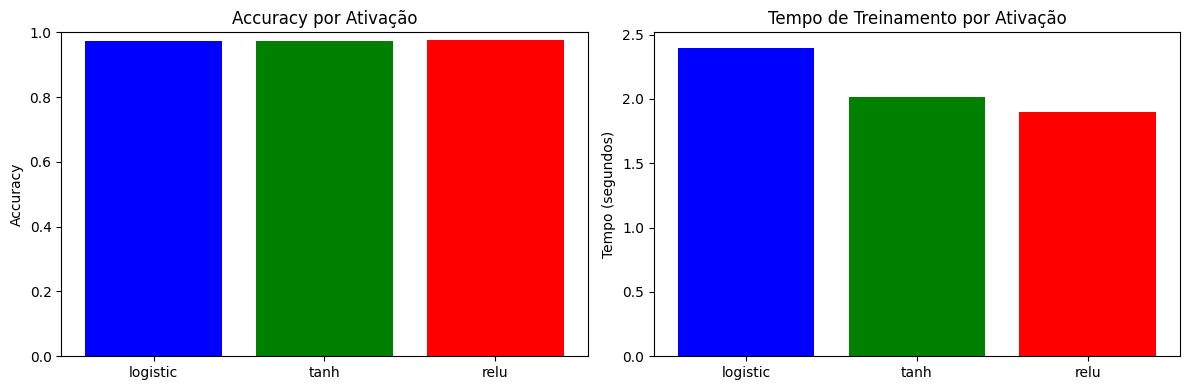


2. COMPARAÇÃO DE ARQUITETURAS
----------------------------------------


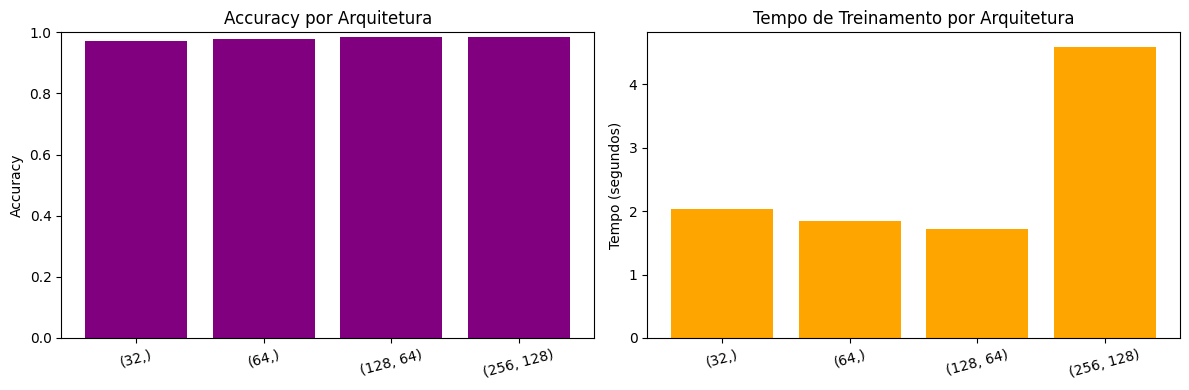


3. COMPARAÇÃO DE LEARNING RATES
----------------------------------------


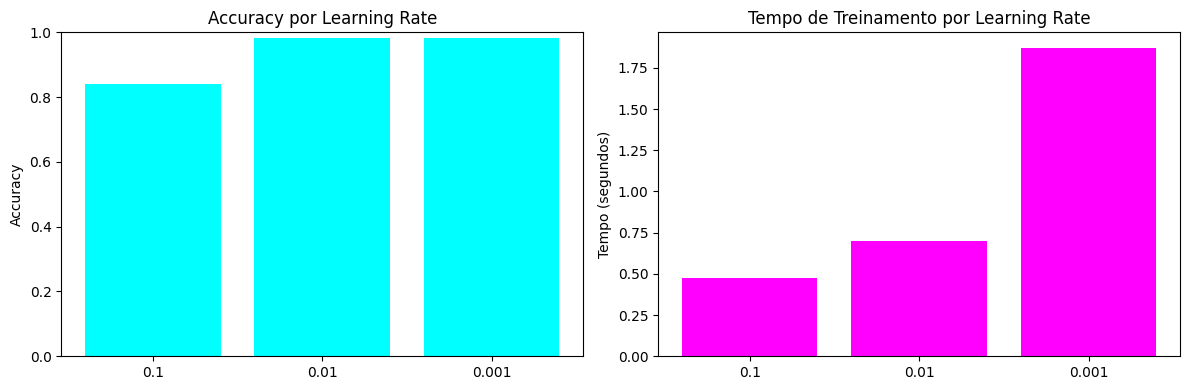


ANÁLISE CONCLUÍDA!

Todos os experimentos foram registrados no MLflow.
Execute 'mlflow ui' no terminal para visualizar os resultados no dashboard.


In [23]:
print("\n" + "=" * 80)
print("VISUALIZAÇÃO DOS RESULTADOS")
print("=" * 80)

# Comparação de ativações
print("\n1. COMPARAÇÃO DE ATIVAÇÕES")
print("-" * 40)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

activations_list = df_activation['activation'].tolist()
accuracy_list = df_activation['accuracy'].tolist()
time_list = df_activation['training_time'].tolist()

ax[0].bar(activations_list, accuracy_list, color=['blue', 'green', 'red'])
ax[0].set_title('Accuracy por Ativação')
ax[0].set_ylabel('Accuracy')
ax[0].set_ylim([0, 1])

ax[1].bar(activations_list, time_list, color=['blue', 'green', 'red'])
ax[1].set_title('Tempo de Treinamento por Ativação')
ax[1].set_ylabel('Tempo (segundos)')

plt.tight_layout()
plt.show()

# Comparação de arquiteturas
print("\n2. COMPARAÇÃO DE ARQUITETURAS")
print("-" * 40)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

arch_list = df_architecture['architecture'].tolist()
acc_arch = df_architecture['accuracy'].tolist()
time_arch = df_architecture['training_time'].tolist()

ax[0].bar(range(len(arch_list)), acc_arch, color='purple')
ax[0].set_xticks(range(len(arch_list)))
ax[0].set_xticklabels(arch_list, rotation=15)
ax[0].set_title('Accuracy por Arquitetura')
ax[0].set_ylabel('Accuracy')
ax[0].set_ylim([0, 1])

ax[1].bar(range(len(arch_list)), time_arch, color='orange')
ax[1].set_xticks(range(len(arch_list)))
ax[1].set_xticklabels(arch_list, rotation=15)
ax[1].set_title('Tempo de Treinamento por Arquitetura')
ax[1].set_ylabel('Tempo (segundos)')

plt.tight_layout()
plt.show()

# Comparação de learning rates
print("\n3. COMPARAÇÃO DE LEARNING RATES")
print("-" * 40)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

lr_labels = [str(lr) for lr in df_learning_rate['learning_rate'].tolist()]
acc_lr = df_learning_rate['accuracy'].tolist()
time_lr = df_learning_rate['training_time'].tolist()

ax[0].bar(lr_labels, acc_lr, color='cyan')
ax[0].set_title('Accuracy por Learning Rate')
ax[0].set_ylabel('Accuracy')
ax[0].set_ylim([0, 1])

ax[1].bar(lr_labels, time_lr, color='magenta')
ax[1].set_title('Tempo de Treinamento por Learning Rate')
ax[1].set_ylabel('Tempo (segundos)')

plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("ANÁLISE CONCLUÍDA!")
print("=" * 80)
print("\nTodos os experimentos foram registrados no MLflow.")
print("Execute 'mlflow ui' no terminal para visualizar os resultados no dashboard.")